# Project 1: Predictive Cell Congestion & Proactive Load Management

**Domain:** 5G/LTE Radio Access Network (RAN) — Capacity Management & SON

**Series:** This is Project 1 of a 3-part RAN Data Science portfolio. All three projects share
the same synthetic dataset generated with `generate_network_data_v3.py`.

---

## Background

In mobile networks, a cell becomes **congested** when its Downlink PRB (Physical Resource Block)
utilization exceeds ~80%. At that point users experience degraded throughput, higher drop rates,
and poor voice quality. Traditional network operations react to congestion *after* it happens.

The industry shift — central to **SON (Self-Organising Networks)** and **RAN automation** in 5G —
is toward **proactive management**: predict congestion 15–30 minutes ahead so the network can
trigger load balancing or traffic steering *before* users are affected.

**In this project you will build exactly that:**
a time-series ML pipeline that predicts whether a cell will be congested in the next 15-minute slot.

---

## Learning Objectives

- Frame a network KPI sequence as a supervised time-series problem
- Build lag and rolling features from raw 15-min counter data
- Handle class imbalance (congestion is a minority event)
- Compare a regression and a binary classification framing of the same problem
- Interpret predictions in terms of real network operations cost

---

## Dataset

| Property | Value |
|---|---|
| File | "network_full_v4_1_20260421_1729.csv" |
| Rows | 229632 (30 sites × 96 slots x mix of 2, 3 and 6 cells) |
| Time Window | 31 days worth of data (2026/01/01-31) |
| Granularity | 15-min slots (slot 0 = 00:00, slot 95 = 23:45) |
| Target | `dl_prb_utilization` (regression) or `prb_congestion` (classification) |

---


---
# Exercise 1 — Data Loading & Time-Series Exploration


## Task 1: Load & inspect the dataset

**Objective:** Load the CSV, parse datetime, and understand the temporal structure.


Things to check:
- How many unique cells are there?
- Are all 96 slots present for every cell? (Use a pivot or groupby to verify)
- What does one cell"s PRB utilization look like over the 96 slots? Plot it.
- What does the distribution of `dl_prb_utilization` look like across all cells and slots?


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "../data/network_full_v4_1_20260422_0846.csv"
#file_path = "../data/network_performance_data_D7H5UT.csv"
df = pd.read_csv(file_path, parse_dates=["datetime"])
df = df.sort_values(["cell_id", "slot"]).reset_index(drop=True)
df["weekday_name"]=df["datetime"].dt.day_name()
df["weekday_int"]=df["datetime"].dt.dayofweek

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 229632 entries, 0 to 229631
Data columns (total 92 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   site_id                      229632 non-null  str           
 1   cell_id                      229632 non-null  str           
 2   site_type                    229632 non-null  str           
 3   technology                   229632 non-null  str           
 4   band                         229632 non-null  int64         
 5   datetime                     229632 non-null  datetime64[us]
 6   slot                         229632 non-null  int64         
 7   hour                         229632 non-null  int64         
 8   minute                       229632 non-null  int64         
 9   avg_active_users             229632 non-null  float64       
 10  max_active_users             229632 non-null  int64         
 11  dl_prb_utilization           229632 n

In [25]:
# How many unique cells?
unique_cell_count = len(df["cell_id"].unique())
print(f"There are {unique_cell_count} unique cells.\n")

# Verify slot completeness for each cell
# Get slot count per cell
# df['Count'] = df.groupby('GroupColumn')['TargetColumn'].transform(lambda x: (x == 'SpecificValue').sum())
slot_count = df.groupby(["cell_id"])["slot"].count()
complete_slot_count = (slot_count == 2944).sum()
print(f"There are {complete_slot_count} cells with a 2944 slots (31 days * 96 slots)")

There are 78 unique cells.

There are 78 cells with a 2944 slots (31 days * 96 slots)


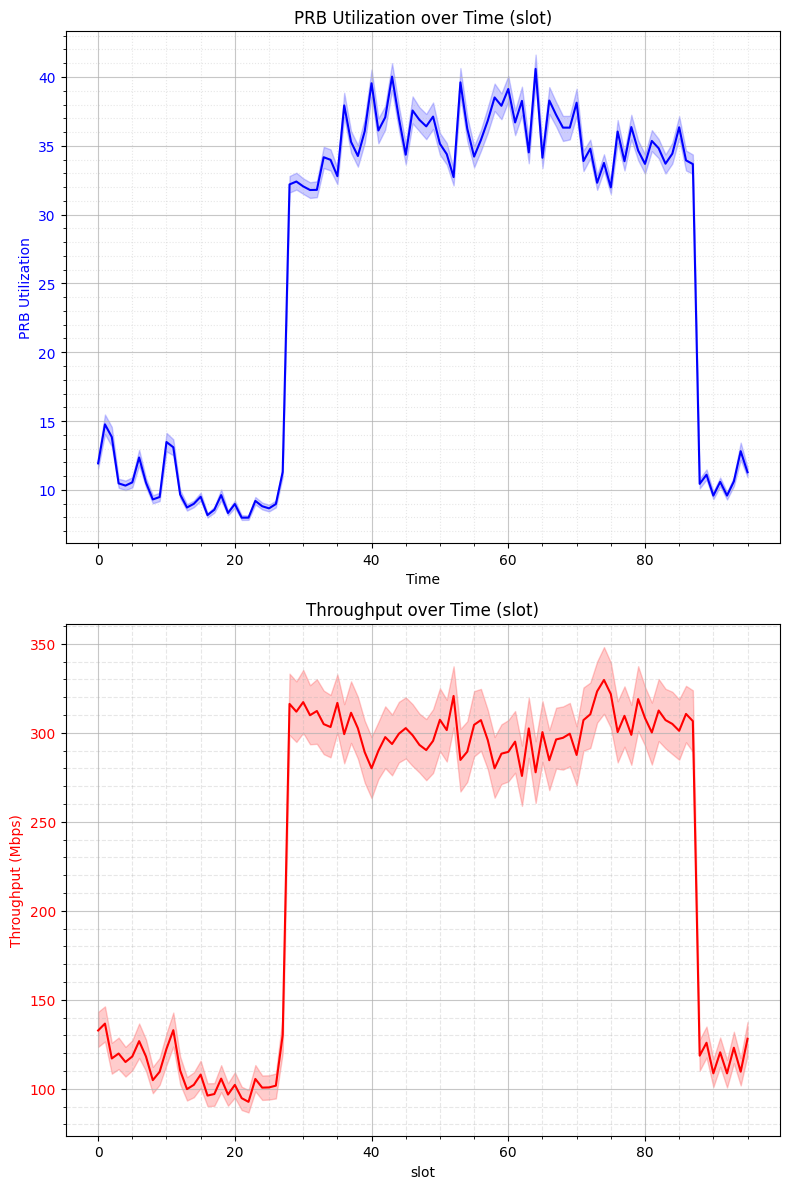

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create the figure and axis
fig, axes = plt.subplots(2, 1, figsize=(8, 12))
# Plot Utilization 
sns.lineplot(data=df, x="slot", y="dl_prb_utilization", ax=axes[0], color="blue")
axes[0].set_ylabel("PRB Utilization", color="blue")
axes[0].set_xlabel("Time")
axes[0].tick_params(axis="y", labelcolor="blue")
axes[0].set_title("PRB Utilization over Time (slot)")
axes[0].minorticks_on()
axes[0].grid(which="major", alpha=0.7)
axes[0].grid(which="minor", alpha=0.3, linestyle=":")
# Create a secondary Y-axis that shares the same X-axis
# Plot Throughput on the secondary Y-axis
sns.lineplot(data=df, x="slot", y="dl_throughput_mbps", ax=axes[1], color="red")
axes[1].set_ylabel("Throughput (Mbps)", color="red")
axes[1].tick_params(axis="y", labelcolor="red")
axes[1].set_title("Throughput over Time (slot)")
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(0.5))  # every 0.5 units
axes[1].yaxis.set_minor_locator(plt.MultipleLocator(0.1))
axes[1].minorticks_on()
axes[1].grid(which="major", alpha=0.7)
axes[1].grid(which="minor", alpha=0.3, linestyle="--")
#plt.suptitle("PRB and Throughput over Time", )
# Optional: if you have multiple cells, you might want to filter for just one cell first!
# e.g., using `data=df[df["cell_id"] == "Cell_A"]`
plt.tight_layout()
plt.show()

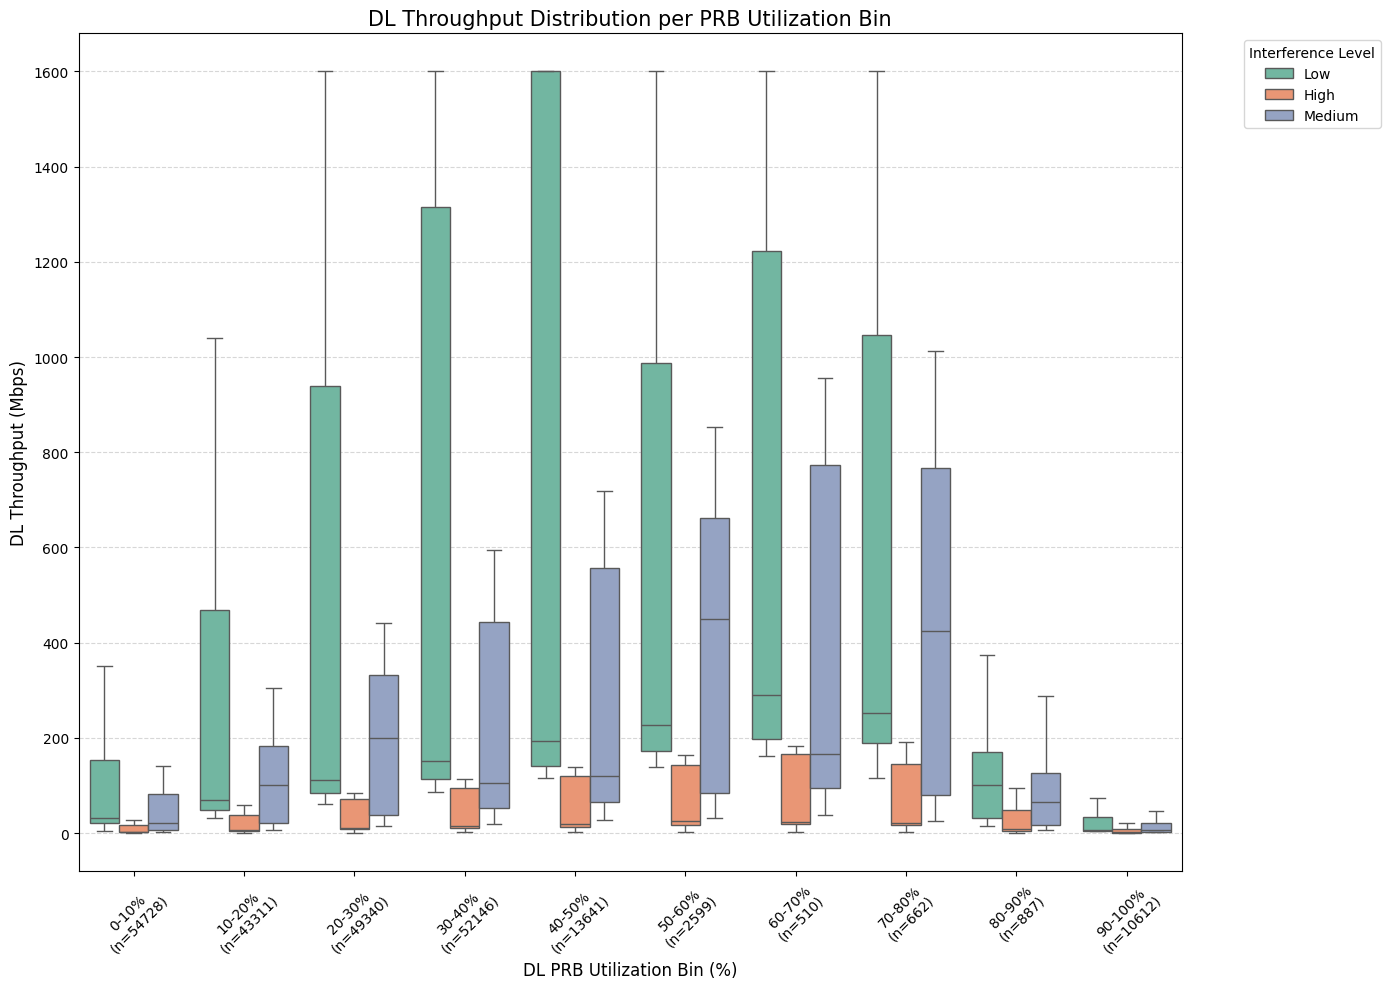

In [23]:
# The previous visualization makes it hard to draw conclusions so we change approach and go for a binned distribution on boxplots
# 1. Create bins for DL PRB Utilization (0% to 100%, increments of 10)
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90-100"]
# Create a new column with these categories
df_binned_prb= df.copy()
df_binned_prb["prb_bin"] = pd.cut(df["dl_prb_utilization"], bins=bins, labels=labels)

# Calculate the count (n) per bin to add to labels
bin_counts = df_binned_prb["prb_bin"].value_counts().sort_index()
# This will map each label to its total count
n_labels = [f"{label}%\n(n={bin_counts[label]})" for label in labels]

# 2. Create the Boxplot per bin
plt.figure(figsize=(14, 10))
ax = sns.boxplot(
    data=df_binned_prb, 
    x="prb_bin", 
    y="dl_throughput_mbps", 
    hue="interference_level", # We consider third variable know to be correlated with both traffic and prb utilization.
                              # "interference_level" is a cathegory variable and helps split each bin further to gain a 
                              # better understanding of PRB vs DL throughput relationship
    palette="Set2",
    showfliers=False           # Optional: set to True if you want to see individual outliers
)
# 3. Update x-axis with labels that already contain bin_counts per label.
ax.set_xticks(ax.get_xticks())
# Then apply your labels safely
ax.set_xticklabels(n_labels)

# 4. Aesthetics
plt.title("DL Throughput Distribution per PRB Utilization Bin", fontsize=15)
plt.xlabel("DL PRB Utilization Bin (%)", fontsize=12)
plt.ylabel("DL Throughput (Mbps)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Interference Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

<details>
<summary>💡 Hint</summary>

```python
# Slot completeness check
slot_counts = df.groupby("cell_id")["slot"].count()
print(slot_counts.describe())  # should all be 96

# Single cell PRB plot
cell = df[df.cell_id == df.cell_id.unique()[0]]
plt.plot(cell["slot"], cell["dl_prb_utilization"])
```
</details>


## Task 2: Understand the target

**Objective:** Explore `prb_congestion` (binary) and `dl_prb_utilization` (continuous) as prediction targets.


Questions to answer:
- What percentage of all cell-slots are congested (`prb_congestion == 1`)?
- Is congestion uniformly distributed across hours, or concentrated in certain slots?
- Are some cells chronically congested while others never are? (Per-cell congestion rate)
- Does congestion vary by technology (LTE vs NR) or site type (Macro vs Indoor)?


In [27]:
df_c = df[["cell_id", "slot", "weekday_name", "dl_prb_utilization", "prb_congestion"]]

# Congestion rate overall. 
congested_rate = (df_c["prb_congestion"]==1).sum() / 179712 *100

# Congestion rate over slot distribution
congested_dist_slot = df_c.groupby(["slot"])["prb_congestion"].mean()

# Congestion rate by hour of day
congested_dist_hour = df.groupby("hour")["prb_congestion"].mean()

# Per-cell congestion rate — which cells are worst?
congested_dist_cell = df.groupby("cell_id")["prb_congestion"].mean().sort_values(ascending=False).head(100)
congested_dist_site = df.groupby("site_id")["prb_congestion"].mean().sort_values(ascending=False).head(20)
# Create a Dataframe for site-cell congestion distribution comparison.sample
cell_congest_means=df.groupby("cell_id")["prb_congestion"].mean().reset_index(drop=True)
site_congest_means=df.groupby("site_id")["prb_congestion"].mean().reset_index(drop=True)
df_site_cell_congest = pd.DataFrame({
    "Cell": cell_congest_means,
    "Site": site_congest_means
})

# By technology and site type
congested_dist_tech_n_sitetype = df.groupby(["technology", "site_type"])["prb_congestion"].sum()



229632

<class 'pandas.DataFrame'>
RangeIndex: 229632 entries, 0 to 229631
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   cell_id             229632 non-null  str    
 1   slot                229632 non-null  int64  
 2   dl_prb_utilization  229632 non-null  float64
 3   prb_congestion      229632 non-null  int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 7.0 MB
None


### Congestin Rate Distribution
In the previous cell, various congestion distributions are obtained mainly to get a clearer picture of the network behaviour at different scopes - time and network wise. 

Establishing a baseline is important to understand what is the overall network behaviour - the raw probability of a cell-slot experiencing congestion across the entire network and timeframe.
In ML, it allows us to understand how to proceed with our dataset. In a typical mobile network, cells are healthy 95-98% of the time, meaning congestion is a minority event. If your overall congestion rate is 3%, you immediately know that standard accuracy metrics won"t work (a model that guesses "no congestion" 100% of the time would be 97% accurate but useless). 

Congestion by Hour give us time resolution. Mobile traffic is strictly driven by human behavior (commuting, lunch breaks, evening streaming). So this becomes one of the strongest predictive features associated to prb utilization and congestion. 

Congestion by Slot gives us even sharper resolution in time domain which is very desireable since true RF (Radio Frequency) congestion happens in bursts. For example, an entire train disembarking at a terminal at 17:15 can spike the dl_prb_utilization to 95% within a single 15-minute slot.

In [29]:
print(f"There is a {congested_rate:.2f}% prb congestion.")
print(f"{df_site_cell_congest.head(30)}")

There is a 6.40% prb congestion.
        Cell      Site
0   0.050951  0.050951
1   0.049932  0.049932
2   0.050272  0.050045
3   0.049592  0.050159
4   0.049932  0.050385
5   0.049253  0.048460
6   0.050951  0.050838
7   0.049253  0.049932
8   0.050272  0.049026
9   0.050951  0.050838
10  0.050951  0.050045
11  0.050272  0.050725
12  0.049932  0.050498
13  0.048234  0.049932
14  0.047215  0.050272
15  0.049932  0.049253
16  0.051291  0.050725
17  0.050611  0.050725
18  0.050611  0.049479
19  0.049932  0.050498
20  0.049253  0.047894
21  0.049253  0.049819
22  0.048573  0.049592
23  0.049932  0.049932
24  0.051630  0.049253
25  0.050951  0.050725
26  0.049932  0.050045
27  0.050611  0.049366
28  0.049592  0.051064
29  0.050611  0.050385


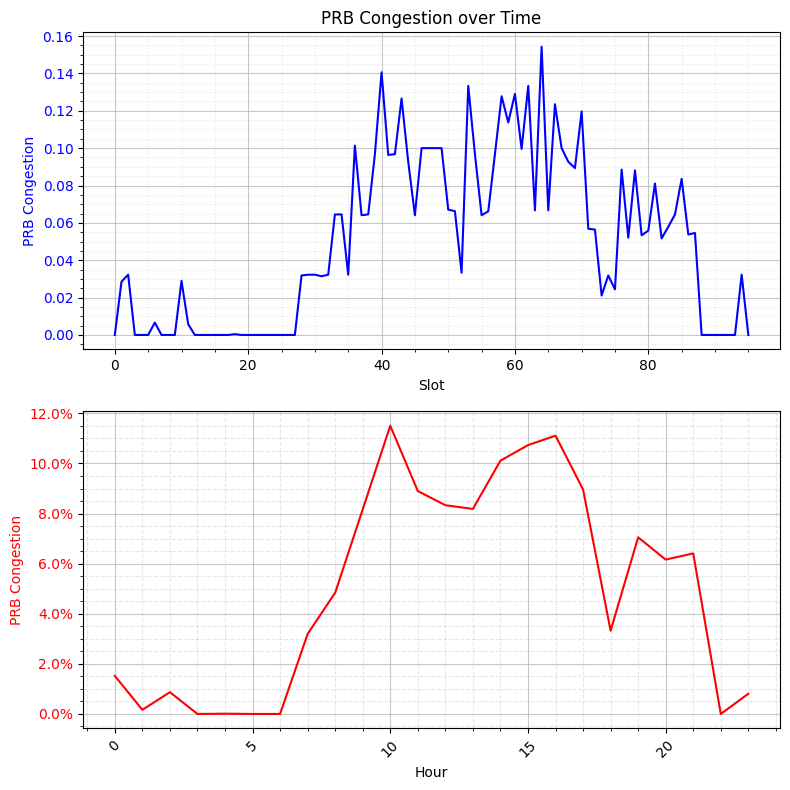

In [30]:
#Graph PRB Congestion
# Import matplotlib formater to improve readability 
from matplotlib.ticker import PercentFormatter
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

sns.lineplot(data=congested_dist_slot, ax=axes[0], color="blue")
axes[0].set_ylabel("PRB Congestion", color="blue")
axes[0].set_xlabel("Slot")
axes[0].tick_params(axis="y", labelcolor="blue")
axes[0].set_title("PRB Congestion over Time")
axes[0].minorticks_on()
axes[0].grid(which="major", alpha=0.7)
axes[0].grid(which="minor", alpha=0.3, linestyle=":")
# Create a secondary Y-axis that shares the same X-axis

sns.lineplot(data=congested_dist_hour, ax=axes[1], color="red")
axes[1].set_ylabel("PRB Congestion", color="red")
axes[1].tick_params(axis="y", labelcolor="red")
axes[1].set_xlabel("Hour")
axes[1].xaxis.set_minor_locator(plt.MultipleLocator(0.5))  # every 0.5 units
axes[1].yaxis.set_minor_locator(plt.MultipleLocator(0.1))
axes[1].minorticks_on()
axes[1].grid(which="major", alpha=0.7)
axes[1].grid(which="minor", alpha=0.3, linestyle="--")

# Configure Y-axis through gca to show percentage scale
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# Format titles, axis labels, ticks and grid.
plt.xticks(rotation=45)
plt.minorticks_on()
plt.grid(which="major", alpha=0.7)
plt.grid(which="minor", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


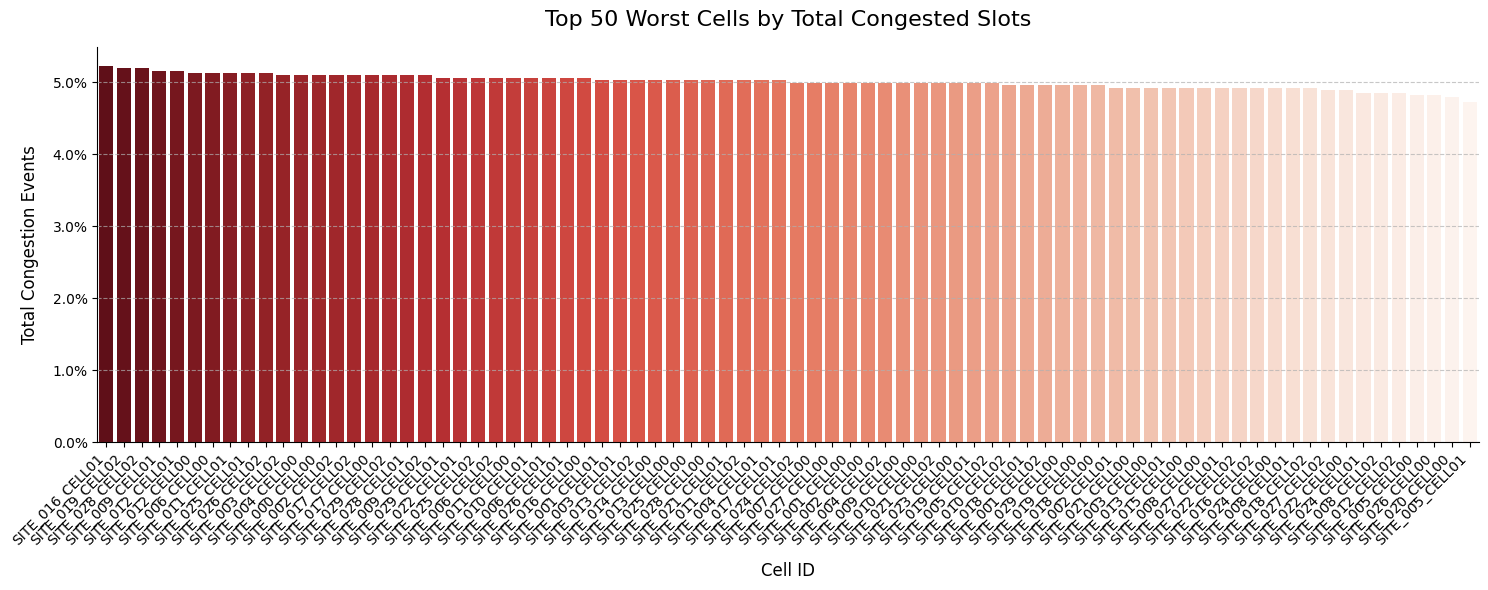

In [33]:
# Boxplot for top 20 Cells with Highest PRB Congestion
plt.figure(figsize=(15, 6))
sns.barplot(
    x=congested_dist_cell.index, 
    y=congested_dist_cell.values, 
    palette="Reds_r",
    hue= congested_dist_cell.index,
    legend=False
)
plt.title("Top 50 Worst Cells by Total Congested Slots", fontsize=16, pad=15)
plt.xlabel("Cell ID", fontsize=12, labelpad=10)
plt.ylabel("Total Congestion Events", fontsize=12, labelpad=10)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

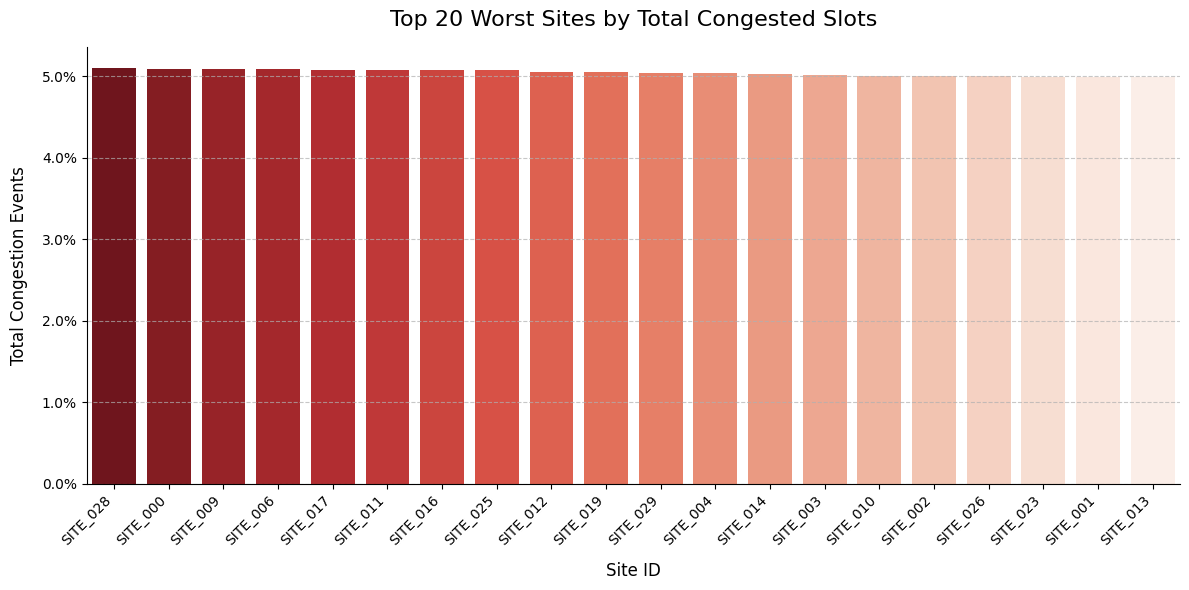

In [34]:
# Boxplot for top 20 Cells with Highest PRB Congestion
plt.figure(figsize=(12, 6))
sns.barplot(
    x=congested_dist_site.index, 
    y=congested_dist_site.values, 
    palette="Reds_r",
    hue= congested_dist_site.index,
    legend=False
)
plt.title("Top 20 Worst Sites by Total Congested Slots", fontsize=16, pad=15)
plt.xlabel("Site ID", fontsize=12, labelpad=10)
plt.ylabel("Total Congestion Events", fontsize=12, labelpad=10)

plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
sns.despine()
plt.tight_layout()
plt.show()

In [35]:
# print distribution statistics Site vs Cell
print(f"{df_site_cell_congest.describe()}")

            Cell       Site
count  78.000000  30.000000
mean    0.050076   0.050026
std     0.000975   0.000747
min     0.047215   0.047894
25%     0.049253   0.049649
50%     0.050102   0.050045
75%     0.050611   0.050668
max     0.052310   0.051064


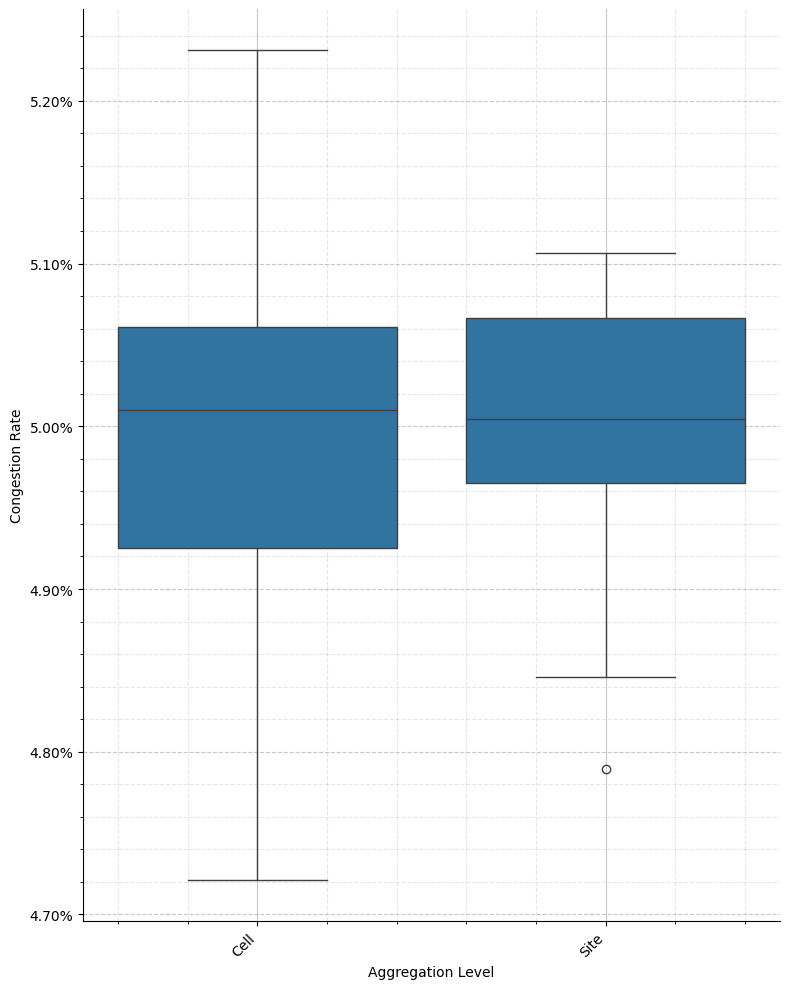

In [36]:
# Graph Congestion Distribution per Site vs Cell
plt.figure(figsize= (8,10))
df_melted = df_site_cell_congest.melt(var_name="Aggregation Level", value_name="Congestion Rate")
sns.boxplot(data=df_melted, x="Aggregation Level", y="Congestion Rate")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
sns.despine()
plt.minorticks_on()
plt.grid(which="major", alpha=0.7)
plt.grid(which="minor", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

### PRB Congestion Distribution Results

From the above results we have: 
- Baseline Congestion Rate of 6.40%. 
- Peak Congestion Window from 6:00 - 21:00 hrs.
- Top 20 Sites with worst PRB Congestion show around 5% Congestion Rate.
- Top 100 Cells with worst PRB Congestion range from 4.8% - 5.2% Congestion Rate.
- Distribution across Site vs Cell as a whole is similar, but cell distributin has a greater variance. 

> **📌 Note**
> This exploration directly informs your ML strategy.
> A 3% overall congestion rate means your classes are imbalanced — you"ll need to handle that in Task 5.


---
# Exercise 2 — Feature Engineering


## Task 3: Create lag features

**Objective:** Build time-lagged versions of key KPIs to give the model historical context.


**Why lag features?** The model needs to see the *trend* leading into a slot, not just the current value.
A cell at 60% PRB and rising is very different from one at 60% PRB and falling.

Create lag features for `dl_prb_utilization`, `avg_active_users`, and `dl_traffic_volume_gb`:
- Lags: t-1, t-2, t-4 (i.e. 15 min, 30 min, 1 hour ago)

**Important:** Lags must be computed *within each cell*. Lagging across cells would leak
data from a different cell into the model. Use `groupby("cell_id")` with `.shift()`.


In [37]:
LAG_COLS = ["dl_prb_utilization", "avg_active_users", "dl_traffic_volume_gb"]
LAG_STEPS = [1, 2, 4]

for col in LAG_COLS:
    for lag in LAG_STEPS:
        df[f"{col}_lag{lag}"] = df.groupby("cell_id")[col].shift(lag)

In [38]:
# How many rows now have NaN in the lag columns? Why?
print(df.isna().sum().tail(9))
print(f"\nShifts t-1= 1872*1={1872*1}")
print(f"\nShifts t-2= 1872*1={1872*2}")
print(f"\nShifts t-4= 1872*1={1872*4}")

dl_prb_utilization_lag1       78
dl_prb_utilization_lag2      156
dl_prb_utilization_lag4      312
avg_active_users_lag1         78
avg_active_users_lag2        156
avg_active_users_lag4        312
dl_traffic_volume_gb_lag1     78
dl_traffic_volume_gb_lag2    156
dl_traffic_volume_gb_lag4    312
dtype: int64

Shifts t-1= 1872*1=1872

Shifts t-2= 1872*1=3744

Shifts t-4= 1872*1=7488


## Task 4: Create rolling and trend features

**Objective:** Summarise recent history with rolling statistics and a simple trend slope.


Add these feature groups:

**Rolling window features** (window = 4 slots = 1 hour):
- `dl_prb_util_rolling_mean_4` — average PRB over the last hour
- `dl_prb_util_rolling_max_4`  — peak PRB over the last hour
- `dl_prb_util_rolling_std_4`  — variability of PRB over the last hour

**Trend feature** (slope of PRB over the last 4 slots):
- A positive slope means utilization is rising — high-value signal for congestion prediction.
- Hint: `np.polyfit(x, y, 1)[0]` returns the slope of a linear fit.

**Time features:**
- `hour` is already in the data — keep it as a categorical feature
- `is_peak_hour` (binary: 1 if hour in [7..20])


In [39]:
# Rolling features — remember to group by cell_id first
grp = df.groupby("cell_id")["dl_prb_utilization"]
# Use transform to avoid misalignment between resulting series and original dataframe
df["dl_prb_util_rolling_mean_4"] = grp.transform(lambda x: x.rolling(window=4, min_periods=1).mean())
df["dl_prb_util_rolling_max_4"]  = grp.transform(lambda x: x.rolling(window=4, min_periods=1).max())
df["dl_prb_util_rolling_std_4"]  = grp.transform(lambda x: x.rolling(window=4, min_periods=1).std())

# Trend slope — apply a rolling window of 4 and fit a line
def rolling_slope(y):
    # Your implementation here
    if len(y)<2:
        return 0.0
    # np.polyfit(x, y, degree) using degree=1, then y= mx +b and so it returns [m, b]
    # in this case our function only returns "m"
    return np.polyfit(range(len(y)), y, 1)[0]

# Apply rolling_slope and use min_periods=2 to avoid loosing too much information.
df["prb_trend_slope"] = grp.transform(
    lambda x: x.rolling(window=4, min_periods=2).apply(rolling_slope, raw=True)
)

# is_peak_hour flag
PEAK_HOURS = list(range(7, 21))
df["is_peak_hour"] = df["hour"].isin(PEAK_HOURS).astype(int)


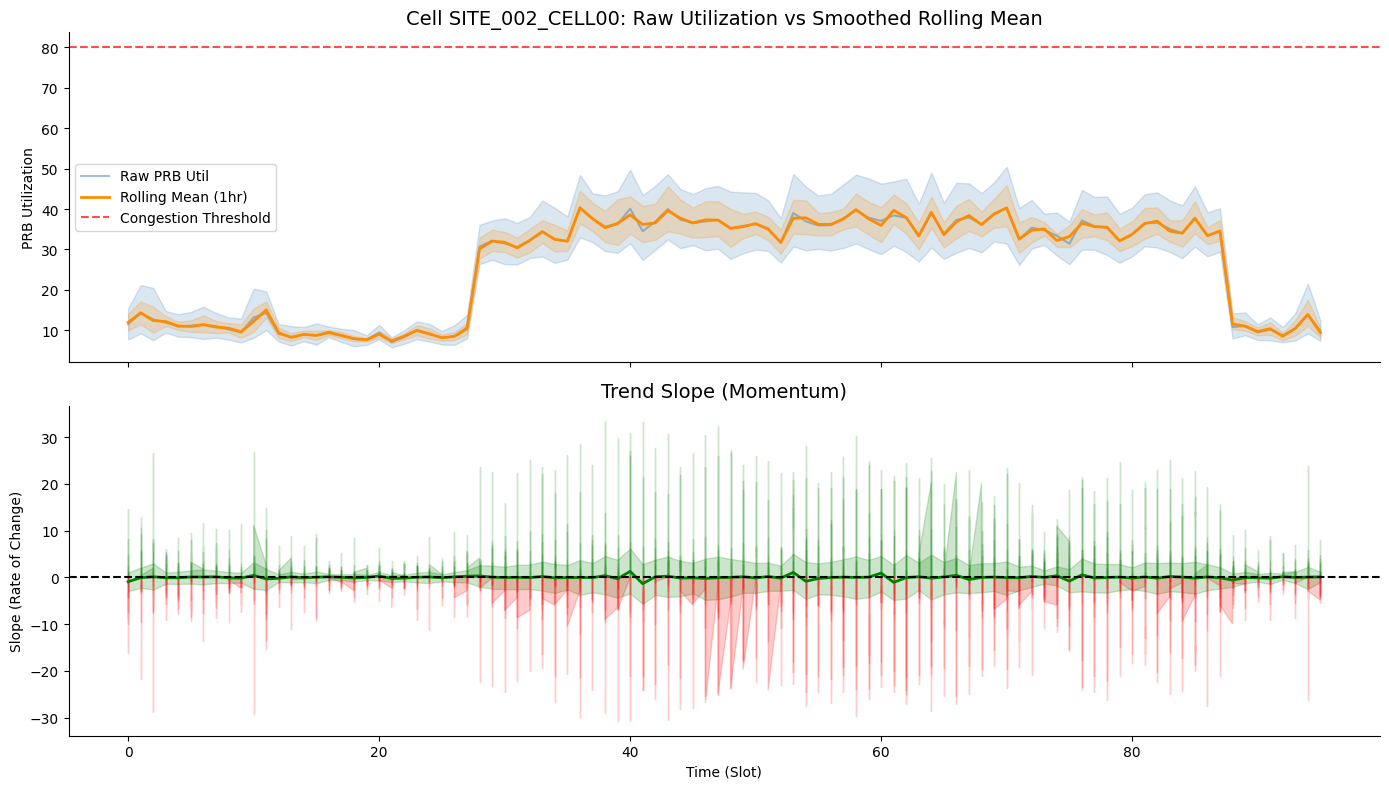

In [40]:
# 1. Filter for a single cell (ideally one that experiences actual congestion!)
sample_cell_id = df[df["prb_congestion"] == 1]["cell_id"].iloc[725]
sample_df = df[df["cell_id"] == sample_cell_id].sort_values("slot")

# 2. Create a stacked plot
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

# Top Plot: Raw Utilization vs. Rolling Mean
sns.lineplot(data=sample_df, x="slot", y="dl_prb_utilization", ax=ax1, label="Raw PRB Util", color="steelblue", alpha=0.5)
sns.lineplot(data=sample_df, x="slot", y="dl_prb_util_rolling_mean_4", ax=ax1, label="Rolling Mean (1hr)", color="darkorange", linewidth=2)

# Assuming congestion happens at 80% (adjust if it"s 0.8 in your dataset) 
ax1.axhline(y=80, color="red", linestyle="--", label="Congestion Threshold", alpha=0.7)
ax1.set_title(f"Cell {sample_cell_id}: Raw Utilization vs Smoothed Rolling Mean", fontsize=14)
ax1.set_ylabel("PRB Utilization")
ax1.legend()

# Bottom Plot: Trend Slope
sns.lineplot(data=sample_df, x="slot", y="prb_trend_slope", ax=ax2, color="green", linewidth=2)
ax2.axhline(y=0, color="black", linestyle="--") # Baseline 0 slope (flat)
ax2.set_title("Trend Slope (Momentum)", fontsize=14)
ax2.set_xlabel("Time (Slot)")
ax2.set_ylabel("Slope (Rate of Change)")

# Fill area under slope for cool visual impact
ax2.fill_between(sample_df["slot"], sample_df["prb_trend_slope"], 0, where=(sample_df["prb_trend_slope"] > 0), color="green", alpha=0.2)
ax2.fill_between(sample_df["slot"], sample_df["prb_trend_slope"], 0, where=(sample_df["prb_trend_slope"] < 0), color="red", alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()


<details>
<summary>💡 Hint</summary>

```python
# Rolling features
grp = df.groupby("cell_id")["dl_prb_utilization"]
df["dl_prb_util_rolling_mean_4"] = grp.transform(lambda x: x.rolling(4, min_periods=1).mean())

# Trend slope using polyfit inside rolling apply
def slope(y):
    if len(y) < 2: return 0.0
    return np.polyfit(range(len(y)), y, 1)[0]

df["prb_trend_slope"] = (df.groupby("cell_id")["dl_prb_utilization"]
                           .transform(lambda x: x.rolling(4, min_periods=2).apply(slope)))
```
</details>


## Task 5: Finalise feature matrix

**Objective:** Drop NaN rows, define X and y, and note the class imbalance.


After creating lag and rolling features, some rows at the start of each cell"s sequence
will have NaN values. Drop them.

Define your feature set and targets:
- **Regression target:** `dl_prb_utilization` (predict the next slot"s value)
- **Classification target:** `prb_congestion` (will the next slot be congested?)

To predict the *next* slot, your target needs to be shifted by -1 within each cell.
Rows where the shifted target is NaN (last slot of each cell) should also be dropped.


In [41]:
# Shift target forward by 1 slot (predict next slot)
df["target_prb_next"]   = df.groupby("cell_id")["dl_prb_utilization"].shift(-1)
df["target_cong_next"]  = df.groupby("cell_id")["prb_congestion"].shift(-1)

# As before, drop rows with NaN after shifting (depending on data handling policy in place.)
df_model = df.dropna().copy()

FEATURE_COLS = [
    # ── Current slot values ───────────────────────────────────────
    "dl_prb_utilization",
    "avg_active_users",
    "avg_sinr_db",
    "avg_rsrp_dbm",
    "cqi_avg",
    "interference_high",
    "poor_coverage",
    "load_balancing_active",
    "massive_event",
    "erab_drop_rate",
    "rach_collision_rate",
    # ── Lag features ─────────────────────────────────────────────
    "dl_prb_utilization_lag1",
    "dl_prb_utilization_lag2",
    "dl_prb_utilization_lag4",
    "avg_active_users_lag1",
    "avg_active_users_lag2",
    "dl_traffic_volume_gb_lag1",
    # ── Rolling features ─────────────────────────────────────────
    "dl_prb_util_rolling_mean_4",
    "dl_prb_util_rolling_max_4",
    "dl_prb_util_rolling_std_4",
    # ── Trend ────────────────────────────────────────────────────
    "prb_trend_slope",
    # ── Time ─────────────────────────────────────────────────────
    "hour",
    "is_peak_hour",
]

X = df_model[FEATURE_COLS]
y_reg  = df_model["target_prb_next"]
y_clf  = df_model["target_cong_next"].astype(int)

# What is the class balance?
print(y_clf.value_counts(normalize=True))


target_cong_next
0    0.949839
1    0.050161
Name: proportion, dtype: float64


---
# Exercise 3 — Train / Test Split (Time-Aware)


## Task 6: Split correctly for time-series data

**Objective:** Use a temporal split — NOT random shuffle — to avoid data leakage.


**This is a critical concept.** In time-series problems, randomly shuffling and splitting
leaks future information into the training set. A model trained this way will appear to
perform well but will fail on truly unseen future data.

**Correct approach:** train on slots 0–71 (first 18 hours), test on slots 72–95 (last 6 hours).

Questions to think about:
- Why is a random train_test_split wrong here?
- What would happen to the lag features if you shuffled first?


In [42]:
TRAIN_SLOTS = list(range(0, 72))   # slots 0-71  = hours 0-17
TEST_SLOTS  = list(range(72, 96))  # slots 72-95 = hours 18-23

train = df_model[df_model["slot"].isin(TRAIN_SLOTS)]
test  = df_model[df_model["slot"].isin(TEST_SLOTS)]

X_train = train[FEATURE_COLS]
X_test  = test[FEATURE_COLS]
y_train_reg = train["target_prb_next"]
y_test_reg  = test["target_prb_next"]
y_train_clf = train["target_cong_next"].astype(int)
y_test_clf  = test["target_cong_next"].astype(int)

print(f"Train size: {len(train):,}  |  Test size: {len(test):,}")
print(f"Test congestion rate: {y_test_clf.mean():.3f}")


Train size: 171,366  |  Test size: 57,876
Test congestion rate: 0.040


---
# Exercise 4 — Modelling


## Task 7: Regression — predict PRB utilization value

**Objective:** Train a baseline and an improved model to predict the continuous PRB value.


**Models to implement:**

1. **Naive baseline:** predict that the next slot"s PRB = current slot"s PRB (last-value carry-forward)
2. **Linear Regression** using a sklearn Pipeline with StandardScaler
3. **LightGBM Regressor** (or RandomForestRegressor if you prefer)

**Metrics:** RMSE, MAE, R²

Plot: actual vs predicted scatter for the best model.


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- Naive baseline ---
y_naive = test["dl_prb_utilization"].values  # current slot value as prediction
rmse_naive = np.sqrt(mean_squared_error(y_test_reg, y_naive))
print(f"Naive RMSE: {rmse_naive:.3f}")

# --- Linear Regression ---
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])
# Fit and evaluate
# 1. Fit the model to the training data
lr_pipe.fit(X_train, y_train_reg)
# 2. Make predictions on the test data
y_pred_lr = lr_pipe.predict(X_test)
# 3. Evaluate the predictions
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
r2_lr = r2_score(y_test_reg, y_pred_lr)
print(f"Linear Regression - RMSE: {rmse_lr:.3f}, MAE: {mae_lr:.3f}, R^2: {r2_lr:.3f}")
# --- LightGBM / RandomForest ---
# ???


Naive RMSE: 22.946
Linear Regression - RMSE: 19.834, MAE: 13.331, R^2: -0.046


In [44]:
from sklearn.ensemble import RandomForestRegressor
# --- Random Forest ---
rf_pipe = Pipeline([
    ("scaler", StandardScaler()), 
    # n_jobs=-1 uses all CPU cores to speed up training
    ("model", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
# Fit, Predict, Evaluate
rf_pipe.fit(X_train, y_train_reg)
y_pred_rf = rf_pipe.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
r2_rf = r2_score(y_test_reg, y_pred_rf)
print(f"Random Forest - RMSE: {rmse_rf:.3f}, R^2: {r2_rf:.3f}")

Random Forest - RMSE: 22.561, R^2: -0.353


In [45]:
!pip install lightgbm

In [46]:
from lightgbm import LGBMRegressor
# --- LightGBM ---
lgb_pipe = Pipeline([
    ("scaler", StandardScaler()), 
    ("model", LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
# Fit, Predict, Evaluate
lgb_pipe.fit(X_train, y_train_reg)
y_pred_lgb = lgb_pipe.predict(X_test)
rmse_lgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_lgb))
r2_lgb = r2_score(y_test_reg, y_pred_lgb)
print(f"LightGBM - RMSE: {rmse_lgb:.3f}, R^2: {r2_lgb:.3f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2120
[LightGBM] [Info] Number of data points in the train set: 171366, number of used features: 22
[LightGBM] [Info] Start training from score 25.920676
LightGBM - RMSE: 21.028, R^2: -0.176


/mnt/c/Users/Diego/projects/ds_portfolio/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [47]:
print(X_train.columns.tolist())
print(X_train.shape)
print(X_train.isna().sum().sum())
print("Train PRB mean:", y_train_reg.mean().round(1))
print("Test PRB mean: ", y_test_reg.mean().round(1))

['dl_prb_utilization', 'avg_active_users', 'avg_sinr_db', 'avg_rsrp_dbm', 'cqi_avg', 'interference_high', 'poor_coverage', 'load_balancing_active', 'massive_event', 'erab_drop_rate', 'rach_collision_rate', 'dl_prb_utilization_lag1', 'dl_prb_utilization_lag2', 'dl_prb_utilization_lag4', 'avg_active_users_lag1', 'avg_active_users_lag2', 'dl_traffic_volume_gb_lag1', 'dl_prb_util_rolling_mean_4', 'dl_prb_util_rolling_max_4', 'dl_prb_util_rolling_std_4', 'prb_trend_slope', 'hour', 'is_peak_hour']
(171366, 23)
0
Train PRB mean: 25.9
Test PRB mean:  26.5


## Task 8: Classification — predict congestion (binary)

**Objective:** Frame the same problem as binary classification and handle class imbalance.


**Class imbalance strategy:** congestion is a minority event (~3%). A model that predicts
"not congested" for every row achieves ~97% accuracy but is completely useless.

Techniques to explore:
- `class_weight="balanced"` in sklearn models
- `scale_pos_weight` in LightGBM / XGBoost
- SMOTE oversampling (from `imbalanced-learn`)

**Evaluation metrics to use — NOT accuracy:**
- Precision, Recall, F1-score
- ROC-AUC
- Confusion matrix
- Precision-Recall curve (more informative than ROC when classes are imbalanced)

**Threshold analysis:** the default 0.5 decision threshold may not be optimal.
Think about the cost asymmetry:
- **False Negative** (missed congestion): users suffer degraded service — high cost
- **False Positive** (false alarm): unnecessary load balancing trigger — low cost
What threshold makes operational sense?


In [50]:
# This was actually added after the cell below resulted in very low numbers. 
# We try this other approach using a cell-level split. 
# # Rebuild train/test with cell-level split (same as regression fix)
all_cells   = df_model['cell_id'].unique()
np.random.seed(10)
test_cells  = np.random.choice(all_cells, size=int(len(all_cells) * 0.2), replace=False)
train_cells = np.setdiff1d(all_cells, test_cells)

train = df_model[df_model['cell_id'].isin(train_cells)]
test  = df_model[df_model['cell_id'].isin(test_cells)]

X_train     = train[FEATURE_COLS]
X_test      = test[FEATURE_COLS]
y_train_clf = train['target_cong_next'].astype(int)
y_test_clf  = test['target_cong_next'].astype(int)

# Check congestion rate is now similar in both sets
print(f"Train congestion rate: {y_train_clf.mean():.3f}")
print(f"Test congestion rate:  {y_test_clf.mean():.3f}")


Train congestion rate: 0.050
Test congestion rate:  0.050


In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix, precision_recall_curve)

# Train with balanced class weights
clf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=10)
# 1. Fit the classifier using the training data
clf.fit(X_train, y_train_clf)

# Evaluate with the default threshold (0.5)
y_pred  = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("--- Default Threshold (0.5) ---")
print(classification_report(y_test_clf, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_proba):.4f}\n")

# 2. Precision-Recall curve
precisions, recalls, thresholds = precision_recall_curve(y_test_clf, y_proba)
# 3. Threshold sweep — find the threshold that maximises F1
# calculate F1 for all thresholds dynamically.
# Note: We slice `[:-1]` because precision and recall arrays return one extra element at the end.
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
# Pull the threshold corresponding to the maximum F1 Score
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]
print(f"Optimal Threshold for F1: {best_threshold:.4f}")
print(f"Maximum F1 Score possible: {best_f1:.4f}\n")
# 4. (Optional) Evaluate the model using the new optimal threshold
print(f"--- Evaluation at Optimized Threshold ({best_threshold:.4f}) ---")
y_pred_best = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test_clf, y_pred_best))


--- Default Threshold (0.5) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     41886
           1       0.85      0.15      0.26      2199

    accuracy                           0.96     44085
   macro avg       0.90      0.57      0.62     44085
weighted avg       0.95      0.96      0.94     44085

ROC-AUC: 0.8754

Optimal Threshold for F1: 0.2100
Maximum F1 Score possible: 0.3936

--- Evaluation at Optimized Threshold (0.2100) ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     41886
           1       0.45      0.35      0.39      2199

    accuracy                           0.95     44085
   macro avg       0.71      0.66      0.68     44085
weighted avg       0.94      0.95      0.94     44085



In [53]:
# Here we try with LightGBM

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
import numpy as np

# Calculate scale_pos_weight = negative samples / positive samples
neg  = (y_train_clf == 0).sum()
pos  = (y_train_clf == 1).sum()
spw  = neg / pos
print(f"scale_pos_weight: {spw:.1f}  (neg={neg:,}  pos={pos:,})")

clf_lgb = LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 63,
    scale_pos_weight  = spw,      # directly tells LightGBM the imbalance ratio
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)
clf_lgb.fit(X_train, y_train_clf)

y_proba_lgb = clf_lgb.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_proba_lgb):.4f}")


scale_pos_weight: 18.9  (neg=175,857  pos=9,300)
ROC-AUC: 0.8990


In [54]:
precisions, recalls, thresholds = precision_recall_curve(y_test_clf, y_proba_lgb)
f1_scores = (2 * precisions[:-1] * recalls[:-1] /
             (precisions[:-1] + recalls[:-1] + 1e-10))

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

# Also find the operationally useful threshold: recall >= 0.60
ops_idx       = np.where(recalls[:-1] >= 0.60)[0]
ops_threshold = thresholds[ops_idx[-1]] if len(ops_idx) > 0 else best_threshold

print(f"\nBest F1 threshold : {best_threshold:.3f}  → F1={f1_scores[best_idx]:.3f}")
print(f"Ops threshold     : {ops_threshold:.3f}  → "
      f"Precision={precisions[ops_idx[-1]]:.3f}, Recall={recalls[ops_idx[-1]]:.3f}")

print("\n--- At Best F1 Threshold ---")
print(classification_report(y_test_clf, (y_proba_lgb >= best_threshold).astype(int)))

print(f"\n--- At Ops Threshold (recall ≥ 0.60) ---")
print(classification_report(y_test_clf, (y_proba_lgb >= ops_threshold).astype(int)))

#=======#
# 1. Get raw probabilities
y_proba_lgb = clf_lgb.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test_clf, y_proba_lgb):.4f}\n")
# 2. Precision-Recall curve & F1 Threshold Sweep
precisions_lgb, recalls_lgb, thresholds_lgb = precision_recall_curve(y_test_clf, y_proba_lgb)
# Slice [:-1] to match the length of the thresholds array
f1_scores_lgb = 2 * (precisions_lgb[:-1] * recalls_lgb[:-1]) / (precisions_lgb[:-1] + recalls_lgb[:-1] + 1e-10)
best_idx_lgb = np.argmax(f1_scores_lgb)
best_threshold_lgb = thresholds_lgb[best_idx_lgb]
print(f"Optimal Threshold for F1: {best_threshold_lgb:.4f}")
print(f"Maximum F1 Score: {f1_scores_lgb[best_idx_lgb]:.4f}\n")
# 3. Evaluate with the newly discovered best threshold!
print(f"--- Evaluation at Optimized Threshold ({best_threshold_lgb:.4f}) ---")
y_pred_best_lgb = (y_proba_lgb >= best_threshold_lgb).astype(int)
print(classification_report(y_test_clf, y_pred_best_lgb))


Best F1 threshold : 0.795  → F1=0.410
Ops threshold     : 0.630  → Precision=0.260, Recall=0.600

--- At Best F1 Threshold ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     41886
           1       0.47      0.37      0.41      2199

    accuracy                           0.95     44085
   macro avg       0.72      0.67      0.69     44085
weighted avg       0.94      0.95      0.94     44085


--- At Ops Threshold (recall ≥ 0.60) ---
              precision    recall  f1-score   support

           0       0.98      0.91      0.94     41886
           1       0.26      0.60      0.36      2199

    accuracy                           0.89     44085
   macro avg       0.62      0.76      0.65     44085
weighted avg       0.94      0.89      0.91     44085

ROC-AUC: 0.8990

Optimal Threshold for F1: 0.7952
Maximum F1 Score: 0.4100

--- Evaluation at Optimized Threshold (0.7952) ---
              precision    recall  f1-score   sup

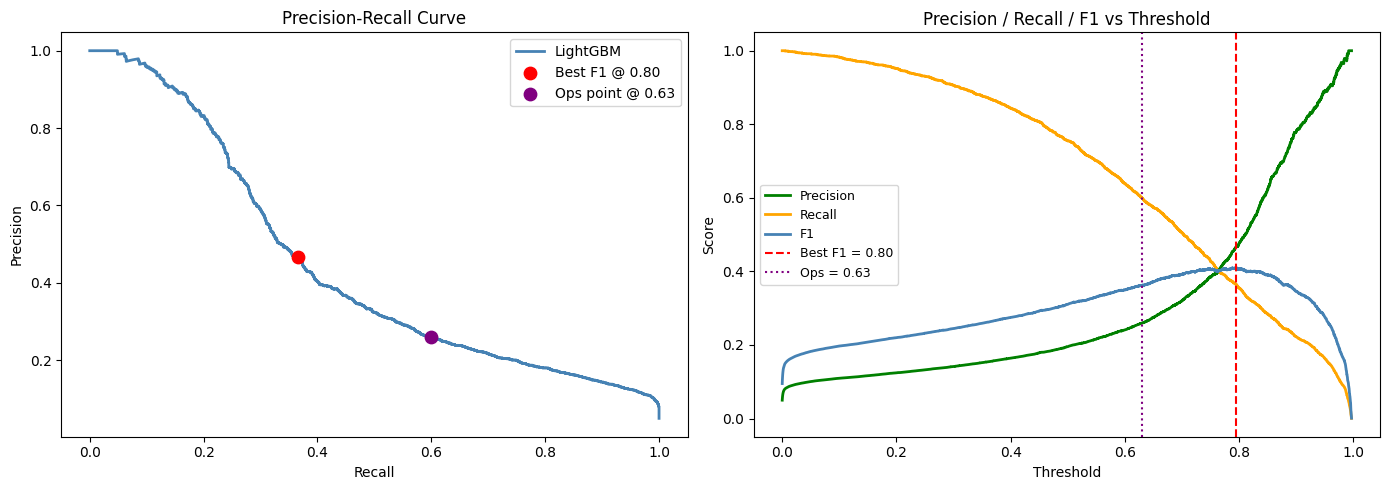

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — PR curve
axes[0].plot(recalls, precisions, color='steelblue', linewidth=2, label='LightGBM')
axes[0].scatter(recalls[best_idx], precisions[best_idx],
                color='red', s=80, zorder=5, label=f'Best F1 @ {best_threshold:.2f}')
if len(ops_idx) > 0:
    axes[0].scatter(recalls[ops_idx[-1]], precisions[ops_idx[-1]],
                    color='purple', s=80, zorder=5,
                    label=f'Ops point @ {ops_threshold:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

# Right — metrics vs threshold
axes[1].plot(thresholds, precisions[:-1], color='green',     linewidth=2, label='Precision')
axes[1].plot(thresholds, recalls[:-1],    color='orange',    linewidth=2, label='Recall')
axes[1].plot(thresholds, f1_scores,       color='steelblue', linewidth=2, label='F1')
axes[1].axvline(best_threshold, color='red',    linestyle='--', label=f'Best F1 = {best_threshold:.2f}')
axes[1].axvline(ops_threshold,  color='purple', linestyle=':',  label=f'Ops = {ops_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---
# Exercise 5 — Interpretation & Evaluation


## Task 9: Feature importance

**Objective:** Understand which features drive the model"s predictions.


For tree-based models (RandomForest, LightGBM), extract feature importances.
Plot the top 15 features as a horizontal bar chart.

Questions to interpret:
- Is the most recent lag (t-1) the most important feature? Why would you expect that?
- Does `prb_trend_slope` contribute meaningfully?
- Do the network condition flags (`interference_high`, `poor_coverage`) add value?

Optional: use **SHAP** for more granular interpretation.
Install: `pip install shap`   |   Use: `shap.TreeExplainer`


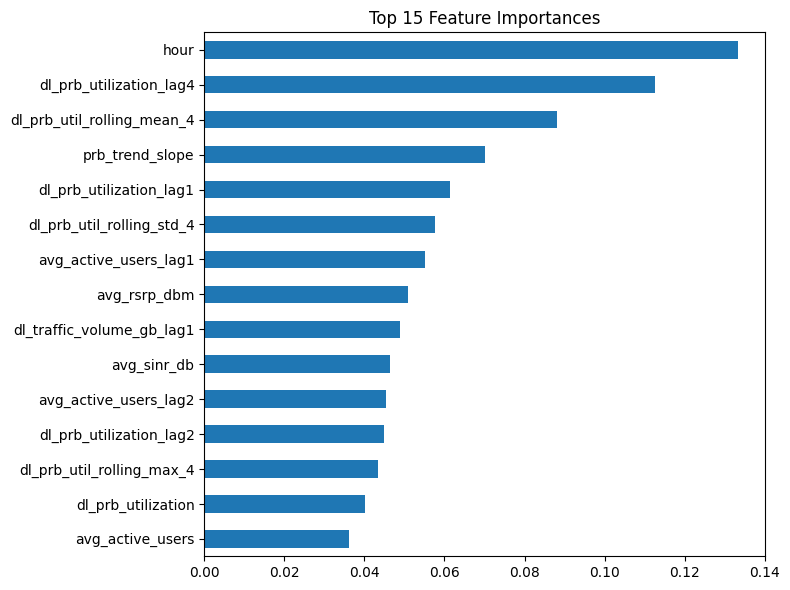

In [56]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

importances.tail(15).plot(kind="barh", figsize=(8, 6))
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()


In [65]:
print(importances.tail(15))

dl_prb_utilization            0.036137
avg_sinr_db                   0.038044
avg_active_users              0.041457
dl_prb_utilization_lag2       0.045459
avg_active_users_lag2         0.046644
dl_prb_util_rolling_max_4     0.046702
avg_rsrp_dbm                  0.050499
dl_traffic_volume_gb_lag1     0.050674
dl_prb_util_rolling_std_4     0.058789
avg_active_users_lag1         0.059280
dl_prb_utilization_lag1       0.067821
prb_trend_slope               0.071724
dl_prb_util_rolling_mean_4    0.088504
dl_prb_utilization_lag4       0.098502
hour                          0.141399
dtype: float64


## Task 10: Operational framing — lead time and alert logic

**Objective:** Translate model output into a simple network operations decision rule.


This final task asks you to think like a network engineer, not just a data scientist.

**Scenario:** your model runs every 15 minutes per cell. When it predicts congestion
for the next slot with probability > threshold, it should trigger a load balancing action.

Build a simple simulation:
1. For each cell-slot in the test set, get the model"s congestion probability
2. Apply your chosen threshold to generate an alert flag
3. Count: how many true congestion events were caught? How many false alarms were generated?
4. Estimate the "detection lead time": for caught events, how many slots before the actual
   congestion did the first alert fire?

Produce a summary table: one row per cell, showing congestion events, caught events,
false alarms, and mean lead time.


In [ ]:
# Build alert simulation
THRESHOLD = 0.35  # adjust based on your precision-recall analysis

test_results = test.copy()
test_results["cong_prob"]  = y_proba
test_results["alert"]      = (test_results["cong_prob"] > THRESHOLD).astype(int)
test_results["actual_cong"]= y_test_clf.values

# Per-cell summary
# ???



---

## Conclusions

Write a brief summary (3-5 bullet points) covering:
- Model performance (RMSE for regression, F1 / ROC-AUC for classification)
- Which features were most predictive and why that makes network sense
- The chosen alert threshold and its operational trade-off
- One limitation of the current approach and how you would address it in a production system

---

## Next Steps

This project is **Part 1 of 3** in the RAN Data Science portfolio series:

- **Project 2** — Unsupervised Cell Anomaly Detection & Root Cause Clustering
  (uses the same dataset; focuses on detecting degraded cells without labels)
- **Project 3** — Spectral Efficiency Scoring & Network Optimisation Dashboard
  (uses the same dataset; focuses on MCS/MIMO efficiency and site-level reporting)
